In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the Preprocessed Dataset

X_train = pd.read_csv("../dataset/X_train.csv")

X_test = pd.read_csv("../dataset/X_test.csv")

y_train = pd.read_csv("../dataset/y_train.csv").squeeze()

y_test = pd.read_csv("../dataset/y_test.csv").squeeze()

In [3]:
# Check Dataset Shape
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (804, 8)
Testing Features : (201, 8)
Training Target : (804,)
Testing Target : (201,)


In [4]:
# Load the Optimized XGBoost Model
model = joblib.load("../saved_models/best_xgboost_model.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [5]:
# Create SHAP Explainer
explainer = shap.TreeExplainer(model)

In [6]:
# Generate SHAP Values
shap_values = explainer.shap_values(X_test)

print(shap_values.shape)

(201, 8)


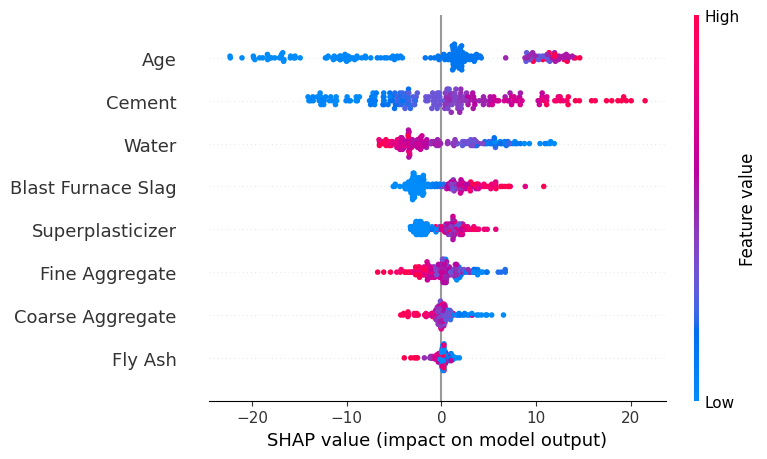

In [7]:
# SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test
)

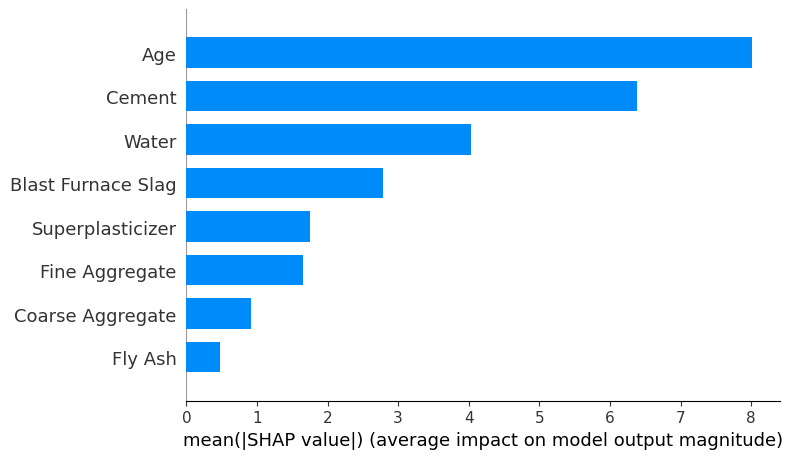

In [8]:
# SHAP Feature Importance (Bar Plot)
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

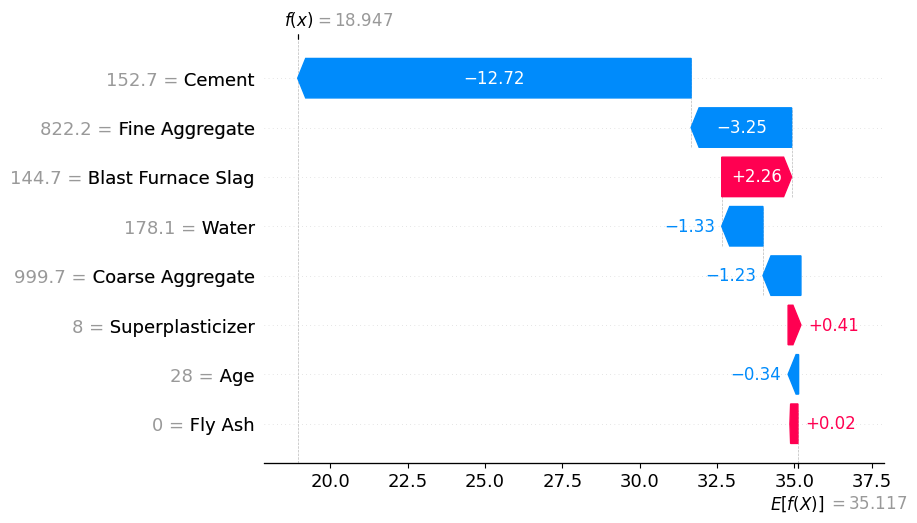

In [9]:
# Waterfall Plot
explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0],
    feature_names=X_test.columns
)

shap.plots.waterfall(explanation)

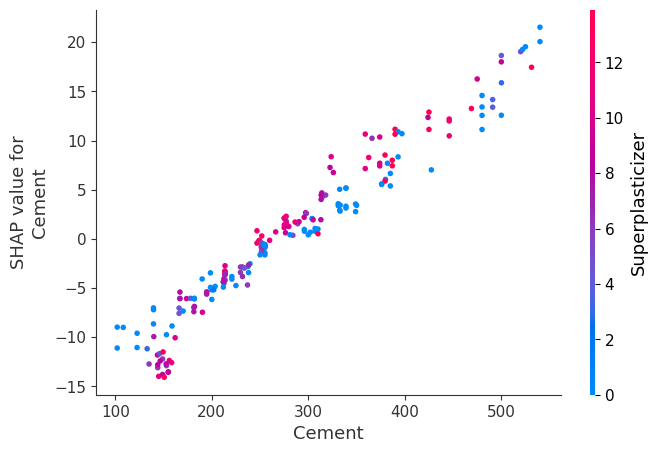

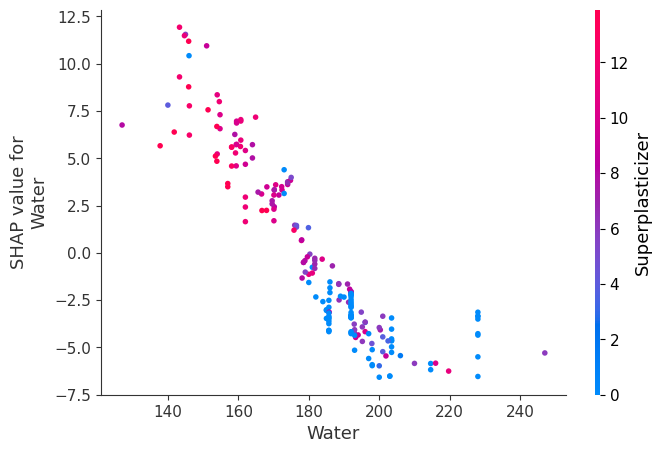

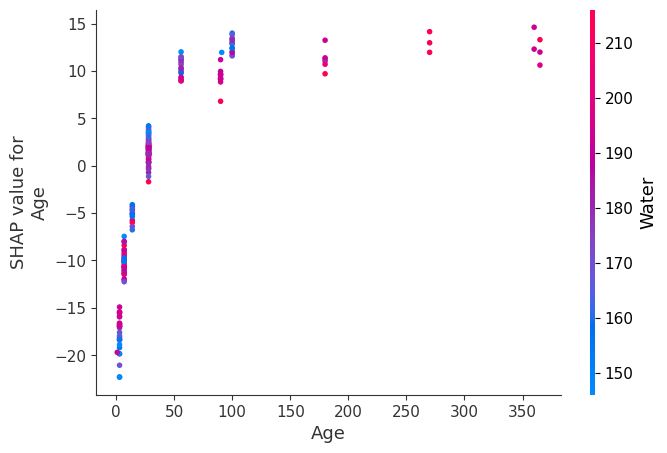

In [10]:
# Dependence Plot – Cement
shap.dependence_plot(
    "Cement",
    shap_values,
    X_test
)
# Dependence Plot – Water
shap.dependence_plot(
    "Water",
    shap_values,
    X_test
)
# Dependence Plot – Age
shap.dependence_plot(
    "Age",
    shap_values,
    X_test
)

In [11]:
# Calculate Feature Importance
importance = pd.DataFrame({

    "Feature": X_test.columns,

    "Mean SHAP Value": np.abs(shap_values).mean(axis=0)

})

importance = importance.sort_values(

    by="Mean SHAP Value",

    ascending=False

)

importance

,Feature,Mean SHAP Value
7,Age,8.006822
0,Cement,6.384784
3,Water,4.025774
1,Blast Furnace Slag,2.781647
4,Superplasticizer,1.752917
6,Fine Aggregate,1.658038
5,Coarse Aggregate,0.920478
2,Fly Ash,0.482517


In [12]:
# Save Feature Importance

importance.to_csv(
    "../results/shap_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


## Observations

- SHAP (SHapley Additive exPlanations) was successfully applied to interpret the predictions of the optimized XGBoost model.

- The SHAP analysis identified **Age**, **Cement**, and **Water** as the three most influential features affecting concrete compressive strength.

- Among all input features, **Age** showed the highest average SHAP value (**8.0068**), followed by **Cement (6.3848)** and **Water (4.0258)**, indicating that these variables have the greatest impact on the model's predictions.

- Features such as **Blast Furnace Slag**, **Superplasticizer**, and **Fine Aggregate** showed a moderate contribution, while **Coarse Aggregate** and **Fly Ash** had comparatively lower influence.

- The SHAP visualizations improve the transparency of the machine learning model by clearly explaining how each input feature contributes to the predicted concrete compressive strength.

- The explainability results successfully address the identified research gap related to the lack of transparency in existing machine learning models and enhance the reliability of the proposed prediction system.